In [10]:
# 必要なライブラリのインポート
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'MS Gothic'

print("ライブラリ読み込み完了！")

ライブラリ読み込み完了！


In [11]:
# SECから企業一覧を取得
url = "https://www.sec.gov/files/company_tickers.json"
headers = {"User-Agent": "hidet test@gmail.com"}

response = requests.get(url, headers=headers)
data = response.json()

print(f"取得成功！総企業数: {len(data)}")

取得成功！総企業数: 10414


In [12]:
# CIKを取得する関数
def get_cik(ticker):
    for i in range(len(data)):
        company = data[str(i)]
        if company['ticker'] == ticker:
            return str(company['cik_str']).zfill(10)
    return None

# 財務データを取得する関数
def get_financial_data(cik, item):
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    response = requests.get(url, headers=headers)
    facts = response.json()
    try:
        raw = facts['facts']['us-gaap'][item]
        df = pd.DataFrame(raw['units']['USD'])
        df_annual = df[df['form'] == '10-K'].copy()
        df_annual['year'] = pd.to_datetime(df_annual['end']).dt.year
        df_annual = df_annual.drop_duplicates(subset='year').sort_values('year')
        df_annual['value'] = (df_annual['val'] / 1e8).round(1)
        return df_annual[['year', 'value']]
    except:
        return None

print("関数定義完了！")

関数定義完了！


In [13]:
# 3社のCIKを取得
nvda_cik = get_cik('NVDA')
amd_cik = get_cik('AMD')
intc_cik = get_cik('INTC')

print(f"NVIDIA: {nvda_cik}")
print(f"AMD: {amd_cik}")
print(f"Intel: {intc_cik}")

NVIDIA: 0001045810
AMD: 0000002488
Intel: 0000050863


In [14]:
# 項目名を自動で選択する関数に改良
def get_revenue(cik):
    # まずRevenuesで試す
    result = get_financial_data(cik, 'Revenues')
    if result is not None and len(result) > 0:
        return result
    # だめならRevenueFromContractWithCustomerExcludingAssessedTaxで試す
    result = get_financial_data(cik, 'RevenueFromContractWithCustomerExcludingAssessedTax')
    return result

# 3社の売上高を取得
nvda_rev = get_revenue(nvda_cik)
amd_rev = get_revenue(amd_cik)
intc_rev = get_revenue(intc_cik)

print(f"NVIDIA: {len(nvda_rev)}年分")
print(f"AMD: {len(amd_rev)}年分")
print(f"Intel: {len(intc_rev)}年分")

NVIDIA: 18年分
AMD: 10年分
Intel: 10年分


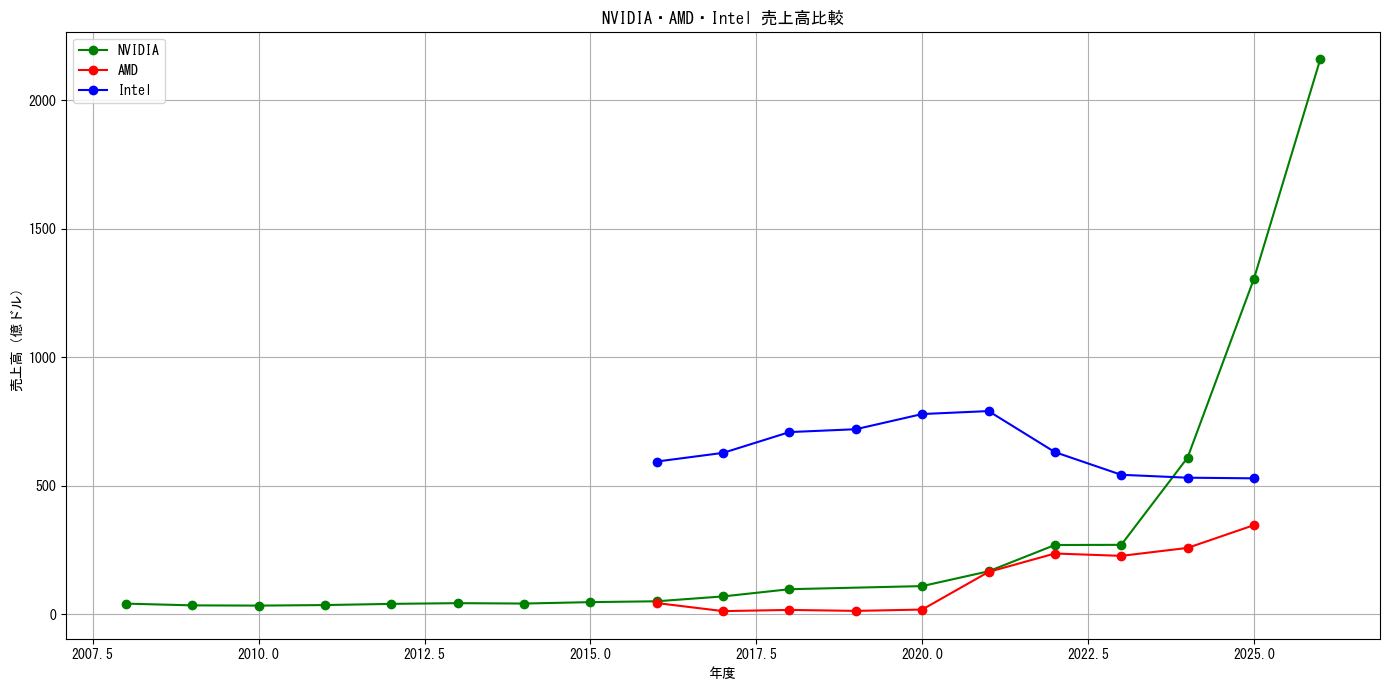

In [15]:
# 3社の売上高を比較グラフ
plt.figure(figsize=(14, 7))

plt.plot(nvda_rev['year'], nvda_rev['value'], marker='o', label='NVIDIA', color='green')
plt.plot(amd_rev['year'], amd_rev['value'], marker='o', label='AMD', color='red')
plt.plot(intc_rev['year'], intc_rev['value'], marker='o', label='Intel', color='blue')

plt.title('NVIDIA・AMD・Intel 売上高比較')
plt.xlabel('年度')
plt.ylabel('売上高（億ドル）')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [16]:
print("AMD 最新3年:")
print(amd_rev.tail(3).to_string())
print("\nIntel 最新3年:")
print(intc_rev.tail(3).to_string())

AMD 最新3年:
     year  value
105  2023  226.8
118  2024  257.8
126  2025  346.4

Intel 最新3年:
    year  value
78  2023  542.3
91  2024  531.0
99  2025  528.5


In [17]:
# 3社のデータを結合してCSV保存
nvda_rev['company'] = 'NVIDIA'
amd_rev['company'] = 'AMD'
intc_rev['company'] = 'Intel'

df_all = pd.concat([nvda_rev, amd_rev, intc_rev])
df_all.columns = ['year', '売上高(億ドル)', 'company']

df_all.to_csv('半導体3社_売上高.csv', index=False, encoding='utf-8-sig')
print("保存完了！")

保存完了！


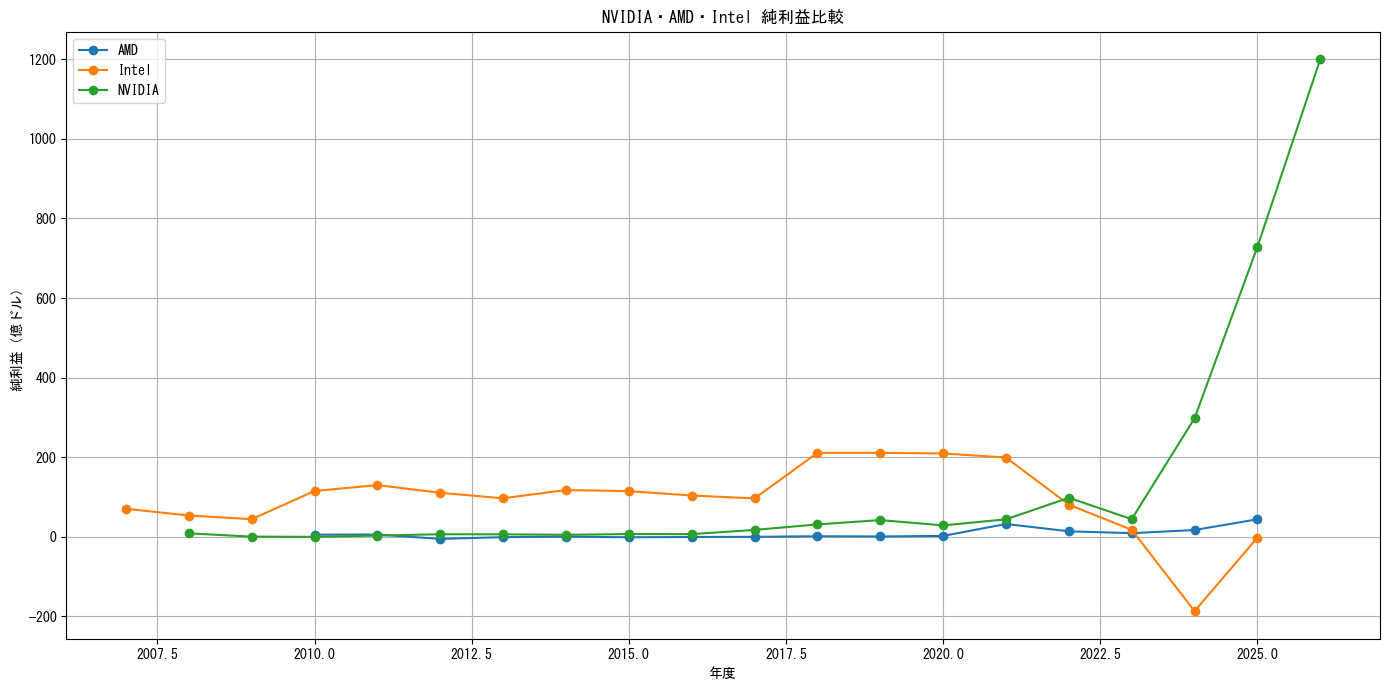

In [18]:
# === 純利益（Net Income）の取得 ===

def get_net_income(cik, name):
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    res = requests.get(url, headers=headers)
    facts = res.json()
    
    try:
        raw = facts["facts"]["us-gaap"]["NetIncomeLoss"]["units"]["USD"]
        df = pd.DataFrame(raw)
        df = df[df["form"] == "10-K"].copy()
        df["year"] = pd.to_datetime(df["end"]).dt.year
        df = df.drop_duplicates(subset="year").sort_values("year")
        df["value"] = (df["val"] / 1e8).round(1)
        df["company"] = name
        return df[["year", "value", "company"]]
    except:
        return None

nvda_ni = get_net_income(nvda_cik, "NVIDIA")
amd_ni  = get_net_income(amd_cik,  "AMD")
intc_ni = get_net_income(intc_cik, "Intel")

ni_df = pd.concat([nvda_ni, amd_ni, intc_ni])

# グラフ表示
plt.figure(figsize=(14, 7))
for name, group in ni_df.groupby("company"):
    plt.plot(group["year"], group["value"], marker="o", label=name)

plt.title("NVIDIA・AMD・Intel 純利益比較")
plt.xlabel("年度")
plt.ylabel("純利益（億ドル）")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()